# IMPORTS

In [256]:
import pandas as pd
import numpy as np
from IPython.display import display
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Column Description

brand:
The brand of the perfume.

title:
The title of the listing.

type:
The type of perfume (e.g., Eau de Parfum, Eau de Toilette).

price:
The price of the perfume.

priceWithCurrency:
The price with currency notation.

available:
The number of items available.

availableText:
Text description of availability.

sold:
The number of items sold.

lastUpdated:
The last updated timestamp of the listing.

itemLocation:
The location of the item.

# CSVs

In [257]:
# Import CSVs
man_sells = 'ebay_mens_perfume.csv'
woman_sells = 'ebay_womens_perfume.csv'

In [258]:
# Reaad CSVs
df1 = pd.read_csv(man_sells)
df2 = pd.read_csv(woman_sells)

# Data Enginnering

In [259]:
# Remove lines whith BLANK cells
df1 = df1.dropna()
df2 = df2.dropna()

In [260]:
# Remove "Price Whitch Currency" Column from DF1
df1 = df1.drop(columns=["priceWithCurrency"])

# Remove "Price Whitch Currency" Column from DF2
df2 = df2.drop(columns=["priceWithCurrency"])

In [261]:
# Convert "Sold" column to whole number
df1["sold"] = df1["sold"].astype(int)
df2["sold"] = df2["sold"].astype(int)

In [262]:
# Split column "itemLocation" to 3 new columns. City, State and Country
split_cols = df1["itemLocation"].str.split(",", n=2, expand=True)

# Rename the columns
df1["city"] = split_cols[0]
df1["state"] = split_cols[1]
df1["country"] = split_cols[2]

df2["city"] = split_cols[0]
df2["state"] = split_cols[1]
df2["country"] = split_cols[2]

# Remove extras spaces
df1["city"] = df1["city"].str.strip()
df1["state"] = df1["state"].str.strip()
df1["country"] = df1["country"].str.strip()

df2["city"] = df1["city"].str.strip()
df2["state"] = df1["state"].str.strip()
df2["country"] = df1["country"].str.strip()

# Remove column "itemLocation"

df1 = df1.drop(columns=["itemLocation"])
df2 = df2.drop(columns=["itemLocation"])

In [263]:
# Split column "availableText" to 2 new columns. Avaliable and Text
split_cols = df1["availableText"].str.split("/", n=1, expand=True)

# Rename the columns
df1["avaliable"] = split_cols[0]
df1["text"] = split_cols[1]

df2["avaliable"] = split_cols[0]
df2["text"] = split_cols[1]

# Remove extras spaces
df1["avaliable"] = df1["avaliable"].str.strip()
df1["text"] = df1["text"].str.strip()

df2["avaliable"] = df1["avaliable"].str.strip()
df2["text"] = df1["text"].str.strip()

# Remove column "itemLocation"

df1 = df1.drop(columns=["availableText"])
df2 = df2.drop(columns=["availableText"])

df1 = df1.drop(columns=["text"])
df2 = df2.drop(columns=["text"])

df1 = df1.drop(columns=["avaliable"])
df2 = df2.drop(columns=["avaliable"])


# Analytics Mens Perfume

In [264]:
def kpis_men(df1):
    print("===== DF1 - MEN'S PERFUMES =====\n")

    # Basic KPIs
    print("Total products:", df1["title"].nunique())
    print("Average price:", df1["price"].mean())
    print("Total sales:", df1["sold"].sum())
    print("Total stock:", df1["available"].sum())

    # Top selling brands
    print("\nTop selling brands:")
    display(df1.groupby("brand")["sold"]
            .sum()
            .sort_values(ascending=False)
            .head(10))

    # Price vs sales correlation
    print("\nPrice vs sales correlation:")
    display(df1[["price", "sold"]].corr())

    # Sales by state
    print("\nSales by state:")
    display(df1.groupby("state")["sold"]
            .sum()
            .sort_values(ascending=False)
            .head(10))

    # Sales by country
    print("\nSales by country:")
    display(df1.groupby("country")["sold"]
            .sum()
            .sort_values(ascending=False))

    # Scatter plot: Price vs Sales
    sns.scatterplot(data=df1, x="price", y="sold")
    plt.title("Price vs Sales Relationship (Men's Perfumes)")
    plt.show()

===== DF1 - MEN'S PERFUMES =====

Total products: 816
Average price: 45.19396674584324
Total sales: 405692
Total stock: 17421.0

Top selling brands:


brand
Versace           44352
Liz Claiborne     21191
Burberry          19286
2nd To None       18882
Armaf             17156
Ralph Lauren      14203
Guy Laroche       13132
Tommy Hilfiger    12528
Myrurgia          11546
Paco Rabanne      11410
Name: sold, dtype: int64


Price vs sales correlation:


,price,sold
price,1.000000,-0.125169
sold,-0.125169,1.000000



Sales by state:


state
Texas            202122
New Jersey       130815
Georgia           21344
Michigan          15314
Florida           11192
New York           9043
California         5618
United States      2092
Rhode Island       1332
Arizona             827
Name: sold, dtype: int64


Sales by country:


country
United States               400656
Hong Kong                     1215
Canada                         564
India                          410
Taiwan                         106
Hong Kong, Hong Kong            41
HongKong, China                 38
USA, Hong Kong                  12
United States, Hong Kong         9
HK, Hong Kong                    4
Name: sold, dtype: int64

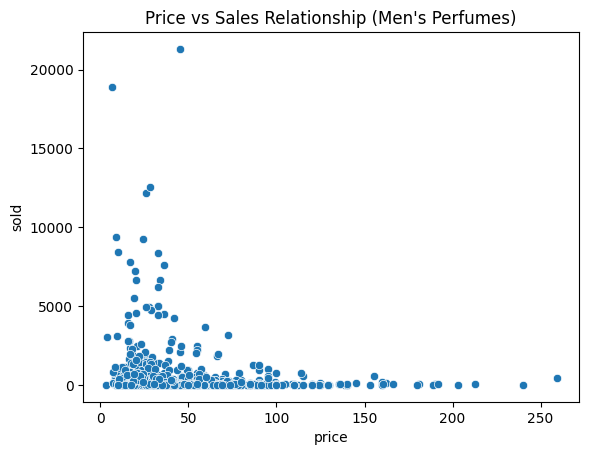

In [265]:
kpis_men(df1)

# Analytics Womens Perfume

In [266]:
def kpis_women(df2):
    print("===== DF2 - WOMEN'S PERFUMES =====\n")

    # Basic KPIs
    print("Total products:", df2["title"].nunique())
    print("Average price:", df2["price"].mean())
    print("Total sales:", df2["sold"].sum())
    print("Total stock:", df2["available"].sum())

    # Top selling brands
    print("\nTop selling brands:")
    display(df2.groupby("brand")["sold"]
            .sum()
            .sort_values(ascending=False)
            .head(10))

    # Price vs sales correlation
    print("\nPrice vs sales correlation:")
    display(df2[["price", "sold"]].corr())

    # Sales by state
    print("\nSales by state:")
    display(df2.groupby("state")["sold"]
            .sum()
            .sort_values(ascending=False)
            .head(10))

    # Sales by country
    print("\nSales by country:")
    display(df2.groupby("country")["sold"]
            .sum()
            .sort_values(ascending=False))

    # Scatter plot: Price vs Sales
    sns.scatterplot(data=df2, x="price", y="sold")
    plt.title("Price vs Sales Relationship (Women's Perfumes)")
    plt.show()

===== DF2 - WOMEN'S PERFUMES =====

Total products: 796
Average price: 38.2938166047088
Total sales: 360187
Total stock: 18056.0

Top selling brands:


brand
Versace              22092
Elizabeth Taylor     20648
Vera Wang            20308
Calvin Klein         17181
Juicy Couture        12349
Jimmy Choo           10833
Gloria Vanderbilt    10268
Perry Ellis           9902
HUGO BOSS             9073
Britney Spears        8025
Name: sold, dtype: int64


Price vs sales correlation:


,price,sold
price,1.000000,-0.175031
sold,-0.175031,1.000000



Sales by state:


state
Texas            71631
New Jersey       49013
Michigan         36845
New York         35871
California       21712
Florida          17647
Nevada           10269
United States     9881
Virginia          9458
Ontario           9218
Name: sold, dtype: int64


Sales by country:


country
United States           267736
Canada                    9273
Hong Kong                 7041
Hong Kong, Hong Kong      2505
Taiwan                    1781
HongKong, China            738
HK, Hong Kong              533
USA, Hong Kong              30
India                       21
Name: sold, dtype: int64

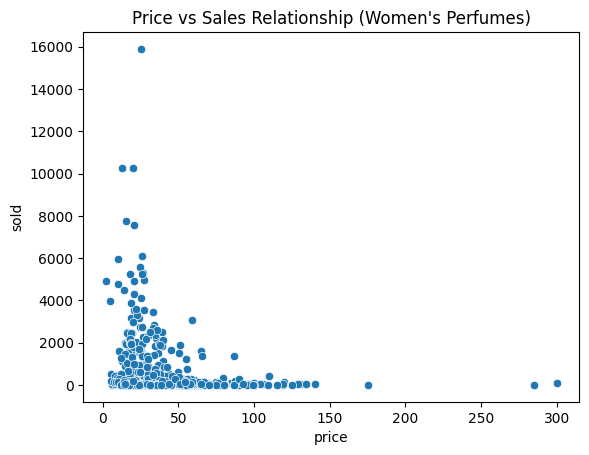

In [267]:
kpis_women(df2)